In [1]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
df=pd.read_csv('spotify_millsongdata.csv')

In [3]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [4]:
df.isnull().sum().isna()

artist    False
song      False
link      False
text      False
dtype: bool

In [5]:
df=df.sample(10000)
df=df.drop('link',axis=1).reset_index(drop=True)

In [6]:
df.shape

(10000, 3)

In [7]:
df

,artist,song,text
0,The Jam,We've Only Started,It's like the middle of a... age \r\nI feel t...
1,Vince Gill,I Still Believe In You,Everybody wants a little piece of my time \r\...
2,Michael W. Smith,End Of The Book,On the day \r\nYou were saved \r\nHeaven and...
3,David Guetta,Commander,I feel like the dj is my bodyguard \r\nYou se...
4,Marillion,She Chameleon,Sheltering her ego on the edge of a floodlit a...
...,...,...,...
9995,Nick Cave,Say Goodbye To The Little Girl Tree,O say goodbye to the little girl tree. \r\nO ...
9996,Rolling Stones,Back Of My Hand,I hear a preacher on the corner \r\nRanting l...
9997,Johnny Cash,Heart Of Gold,"I want to live, \r\nI want to give \r\nI've ..."
9998,Indigo Girls,Little Darling,Hey little darling \r\nTheres something that ...


text cleaning 


In [8]:
all_lyrics= " ".join(df['text'].dropna())
wordcloud= WordCloud(width=800,height=400,background_color='white').generate(all_lyrics)

visualise the most common words iin the lyrics

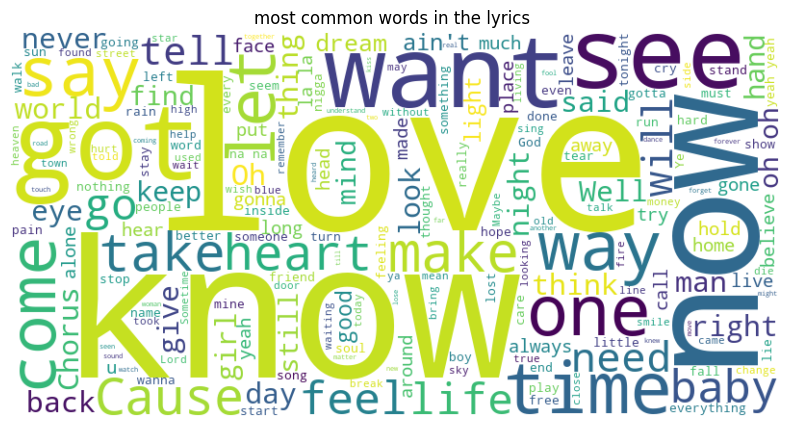

In [9]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation= 'bilinear' )
plt.axis('off')
plt.title('most common words in the lyrics ')
plt.show()

data preprocessing


In [11]:

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rajshrestha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rajshrestha/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rajshrestha/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
stop_words=set(stopwords.words('english'))

In [15]:
def preprocess_text(text):
    text=re.sub(r" [^a-zA-Z\s]", "",text)
    text=text.lower()
    tokens=word_tokenize(text)
    tokens= [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [16]:
df['cleaned_text']=df['text'].apply(preprocess_text)


In [17]:
tfidf_vectorizer=TfidfVectorizer(max_features= 5000)
tfidf_matrix= tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [18]:
cosine_sim=cosine_similarity(tfidf_matrix,tfidf_matrix)

In [21]:
def recommend_songs(song_name,cosine_sim=cosine_sim,df=df,top_n=5):
    idx=df[df['song'].str.lower()==song_name.lower()].index
    if len(idx)==0:
        return 'Song not found'
    idx = idx[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores,key=lambda x: x[1],reverse= True)
    sim_scores = sim_scores[1:top_n+1]

    song_indices = [i[0] for i in sim_scores]

    return df[['artist','song']].iloc[song_indices]
    

In [22]:
df['song'][2]

'End Of The Book'

In [28]:
print("\n Recommendations for the song ")
recommendations = recommend_songs('wish you were here')
print(recommendations)


 Recommendations for the song 
             artist                          song
4805        Incubus            Wish You Were Here
8425      Meat Loaf             Love You Out Loud
1570     Gary Numan        A Child With The Ghost
4868  Talking Heads  I Wish You Wouldn't Say That
5532        X Japan                  White Poem I


ARKO VIDEO KO


In [9]:
df['text']=df['text'].str.lower().replace(r'^w\s',' ').replace(r'\n', ' ',regex=True)

In [10]:
df

,artist,song,text
0,ABBA,Ahe's My Kind Of Girl,"look at her face, it's a wonderful face \r an..."
1,ABBA,"Andante, Andante","take it easy with me, please \r touch me gent..."
2,ABBA,As Good As New,i'll never know why i had to go \r why i had ...
3,ABBA,Bang,making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,making somebody happy is a question of give an...
...,...,...,...
57645,Ziggy Marley,Good Old Days,irie days come on play \r let the angels fly ...
57646,Ziggy Marley,Hand To Mouth,power to the workers \r more power \r power ...
57647,Zwan,Come With Me,all you need \r is something i'll believe \r...
57648,Zwan,Desire,northern star \r am i frightened \r where ca...


In [11]:
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


False

In [12]:
stemmer=PorterStemmer()
from nltk.tokenize import word_tokenize

In [13]:
def token(txt):
    token=word_tokenize(txt)
    a=[stemmer.stem(w) for w in token]
    return " ".join(a)

In [14]:
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def token(txt):
    tokens = word_tokenize(txt, preserve_line=True)  # ← no punkt needed
    a = [stemmer.stem(w) for w in tokens]
    return " ".join(a)

print(token("you are beautiful,beauty"))


you are beauti , beauti


In [15]:
df['text'].apply(lambda x :token(x))

0        look at her face , it 's a wonder face and it ...
1        take it easi with me , pleas touch me gentli l...
2        i 'll never know whi i had to go whi i had to ...
3        make somebodi happi is a question of give and ...
4        make somebodi happi is a question of give and ...
                               ...                        
57645    iri day come on play let the angel fli let the...
57646    power to the worker more power power to the wo...
57647    all you need is someth i 'll believ flashlight...
57648    northern star am i frighten where can i go to ...
57649    come in make yourself at home i 'm a bit late ...
Name: text, Length: 57650, dtype: object

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
tfid=TfidfVectorizer(analyzer='word',stop_words='english')

: 

In [ ]:
similar[0]

NameError: name 'similar' is not defined

In [ ]:
df[df['song']== " Ahe's My Kind Of Girl "].index[0]


NameError: name 'df' is not defined